<a href="https://colab.research.google.com/github/SusanPeter05/AI-ML-INTERNSHP/blob/main/image_preprocessing_assignmet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from PIL import Image


In [7]:
                                                                                 import os

print(os.path.exists('/content/archive.zip'))
print(os.path.getsize('/content/archive.zip'))

True
444540604


In [8]:
!file "/content/archive.zip"

/content/archive.zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [9]:
import os
print(os.listdir('/content'))

['.config', 'archive.zip', 'sample_data']


In [13]:
import os

print(os.listdir("/content/dataset")[:20])

['test', 'EfficientNetB0-100-(224 X 224)- 98.40.h5', 'train', 'valid', 'sports.csv']


In [14]:
from glob import glob

image_paths = glob("/content/dataset/**/*.jpg", recursive=True)
image_paths += glob("/content/dataset/**/*.jpeg", recursive=True)
image_paths += glob("/content/dataset/**/*.png", recursive=True)

print("Total Images:", len(image_paths))

Total Images: 14492


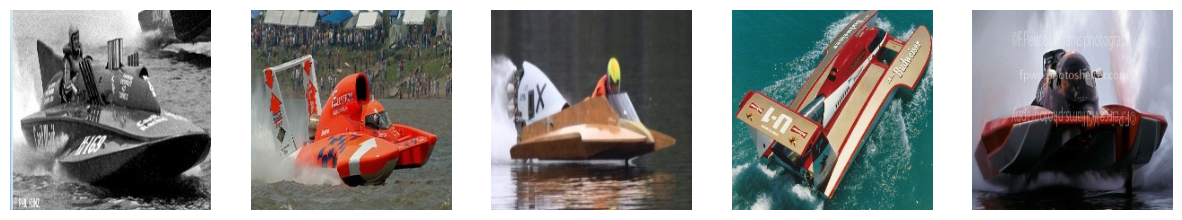

In [15]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [16]:
import pandas as pd
import cv2
import os

data = []

for path in image_paths[:100]:   # use first 100 images
    img = cv2.imread(path)

    if img is not None:
        h, w, c = img.shape
        data.append([os.path.basename(path), h, w, c])

df = pd.DataFrame(data,
                  columns=["Image","Height","Width","Channels"])

df.head()

,Image,Height,Width,Channels
0,3.jpg,224,224,3
1,1.jpg,224,224,3
2,4.jpg,224,224,3
3,2.jpg,224,224,3
4,5.jpg,224,224,3


In [17]:
sample = cv2.imread(image_paths[0])
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

resized = cv2.resize(sample, (224,224))

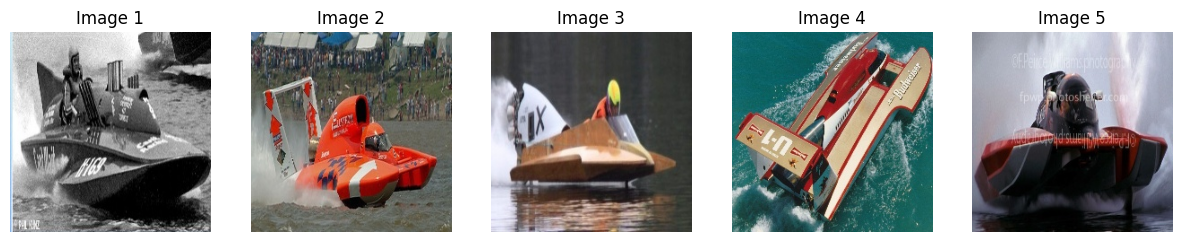

In [18]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [19]:
import pandas as pd
import cv2
import os

data = []

for path in image_paths[:100]:
    img = cv2.imread(path)

    if img is not None:
        h, w, c = img.shape

        data.append([
            os.path.basename(path),
            h,
            w,
            c
        ])

df = pd.DataFrame(
    data,
    columns=["Image", "Height", "Width", "Channels"]
)

df.head()

,Image,Height,Width,Channels
0,3.jpg,224,224,3
1,1.jpg,224,224,3
2,4.jpg,224,224,3
3,2.jpg,224,224,3
4,5.jpg,224,224,3


In [20]:
df.to_csv("image_dimensions.csv", index=False)

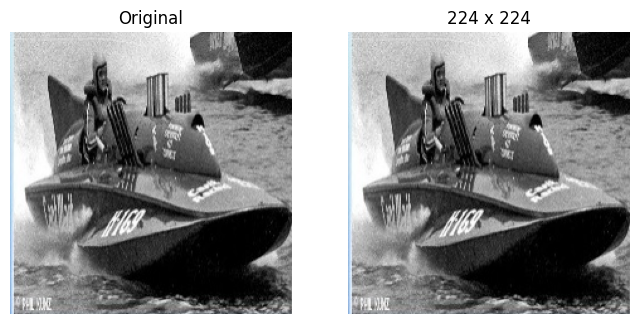

In [21]:
sample = cv2.imread(image_paths[0])
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

resized = cv2.resize(sample, (224,224))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title("224 x 224")
plt.axis("off")

plt.show()

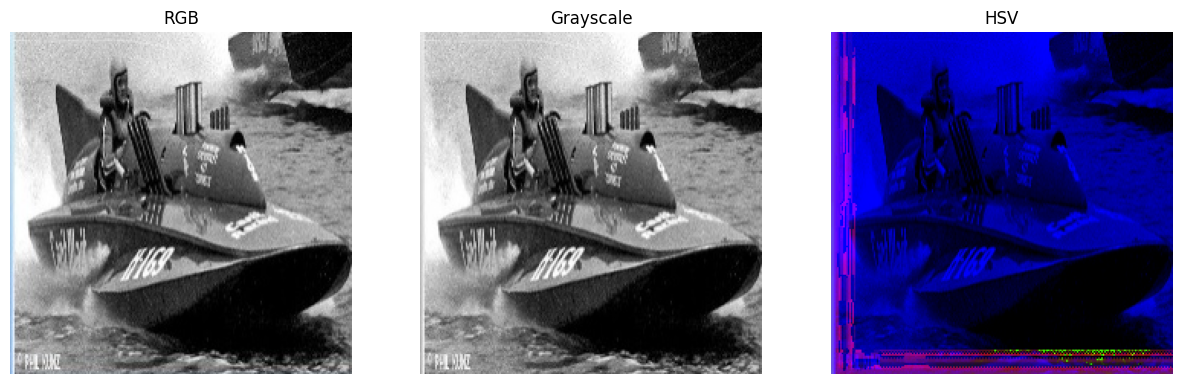

In [22]:
gray = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(sample, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

In [23]:
normalized = sample / 255.0

print("Before Normalization")
print("Min =", sample.min())
print("Max =", sample.max())

print("\nAfter Normalization")
print("Min =", normalized.min())
print("Max =", normalized.max())

Before Normalization
Min = 0
Max = 255

After Normalization
Min = 0.0
Max = 1.0


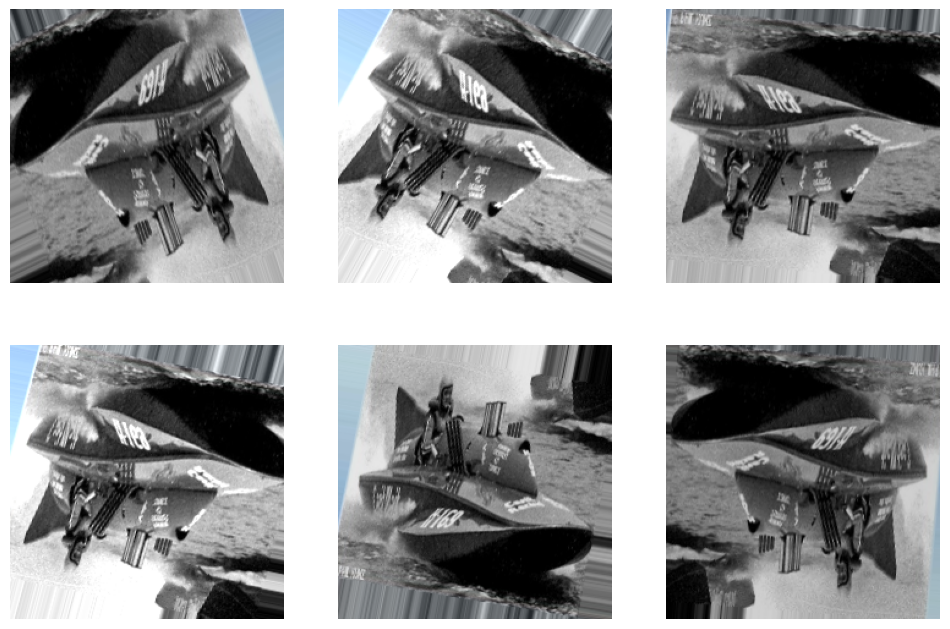

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7,1.3]
)

img = cv2.resize(sample, (224,224))
img = np.expand_dims(img, axis=0)

aug_iter = datagen.flow(img, batch_size=1)

plt.figure(figsize=(12,8))

for i in range(6):
    batch = next(aug_iter)

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")

plt.show()

In [25]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    return img


processed = preprocess_image(image_paths[0])

print("Shape:", processed.shape)
print("Min:", processed.min())
print("Max:", processed.max())

Shape: (224, 224, 3)
Min: 0.0
Max: 1.0
